In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("train_cleaned.csv")

#this makes charts appear inside the notebook
%matplotlib inline

print("Libraries loaded successfully!")
print("Shape:", df.shape)

Libraries loaded successfully!
Shape: (9800, 18)


In [4]:
#statistical summary of all numeeric columns
df.describe()

,Postal Code,Sales,Shipping Days
count,9800.000000,9800.000000,9800.000000
mean,55217.343265,230.769059,3.961122
std,32066.750532,626.651875,1.749614
min,1040.000000,0.444000,0.000000
25%,23223.000000,17.248000,3.000000
50%,57551.000000,54.490000,4.000000
75%,90008.000000,210.605000,5.000000
max,99301.000000,22638.480000,7.000000


In [6]:
#How many unique values in each categorical column
print("Categories:", df['Category'].unique())
print("Sub-Categories:", df['Sub-Category'].nunique())
print("Regions:", df['Region'].unique())
print("Segments:", df['Segment'].unique())

Categories: <StringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str
Sub-Categories: 17
Regions: <StringArray>
['South', 'West', 'Central', 'East']
Length: 4, dtype: str
Segments: <StringArray>
['Consumer', 'Corporate', 'Home Office']
Length: 3, dtype: str


In [7]:
sales_by_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(sales_by_category)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


Insights #1: Technology generates the highest revenue, even though it likely has fewer items sold (electronics cost more per unit). We'll confirm this later with quantity data.

In [8]:
#Convert the sales column to a Numpy array 
sales_array = df['Sales'].values
print(type(sales_array))

#common Numpy operations
print("Mean:", np.mean(sales_array))
print("Median:", np.median(sales_array))
print("Standard deviation:", np.std(sales_array))
print("Maximum:", np.max(sales_array))

<class 'numpy.ndarray'>
Mean: 230.76905945918367
Median: 54.489999999999995
Standard deviation: 626.619901988719
Maximum: 22638.48


Insight #2: The mean is 4x higher than the median. This is a classic sign of outliners - a few very expensive orders (like the 22,638 one) are pulling the average way up, while most orders are actually small (54 approx).

C:\Users\K Shridharan\AppData\Local\Temp\ipykernel_21476\594798443.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_category.index, y=sales_by_category.values, palette = 'Set2')


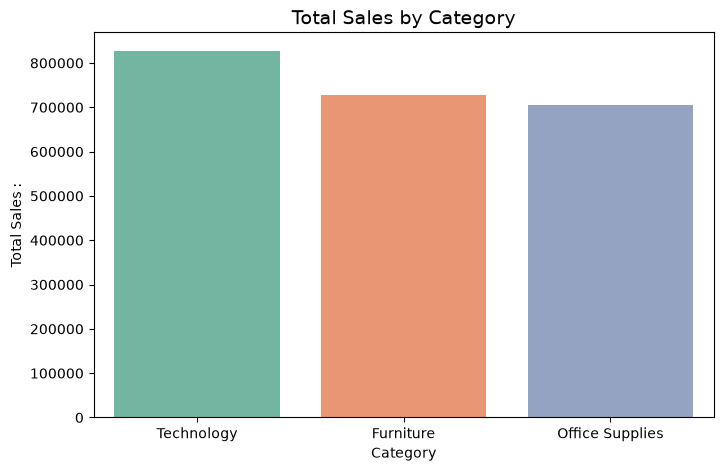

In [13]:
#Bar Chart
plt.figure(figsize=(8,5))
sns.barplot(x=sales_by_category.index, y=sales_by_category.values, palette = 'Set2')
plt.title('Total Sales by Category', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Total Sales :')
plt.show()

In [15]:
#Pie chart
sales_by_region = df.groupby('Region')['Sales'].sum()
print(sales_by_region)

Region
Central    492646.9132
East       669518.7260
South      389151.4590
West       710219.6845
Name: Sales, dtype: float64


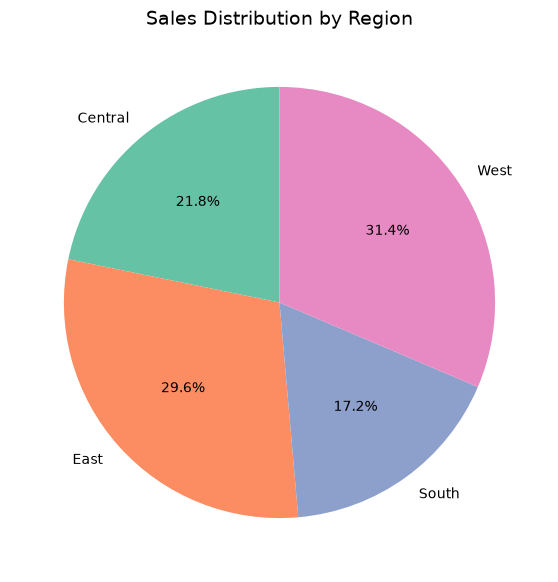

In [19]:
plt.figure(figsize=(7, 7))
plt.pie(sales_by_region.values, labels = sales_by_region.index, autopct='%1.1f%%', colors=sns.color_palette('Set2'), startangle = 90)
plt.title('Sales Distribution by Region', fontsize = 14)
plt.show()

In [20]:
print(df['Order Date'].dtype)

str


In [21]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
print(df['Order Date'].dtype)

datetime64[us]


In [23]:
df['Order Month'] = df['Order Date'].dt.to_period('M')

monthly_sales = df.groupby('Order Month')['Sales'].sum()
print(monthly_sales)

Order Month
2015-01     14205.7070
2015-02      4519.8920
2015-03     55205.7970
2015-04     27906.8550
2015-05     23644.3030
2015-06     34322.9356
2015-07     33781.5430
2015-08     27117.5365
2015-09     81623.5268
2015-10     31453.3930
2015-11     77907.6607
2015-12     68167.0585
2016-01     18066.9576
2016-02     11951.4110
2016-03     32339.3184
2016-04     34154.4685
2016-05     29959.5305
2016-06     23599.3740
2016-07     28608.2590
2016-08     36818.3422
2016-09     63133.6060
2016-10     31011.7375
2016-11     75249.3995
2016-12     74543.6012
2017-01     18542.4910
2017-02     22978.8150
2017-03     51165.0590
2017-04     38679.7670
2017-05     56656.9080
2017-06     39724.4860
2017-07     38320.7830
2017-08     30542.2003
2017-09     69193.3909
2017-10     59583.0330
2017-11     79066.4958
2017-12     95739.1210
2018-01     43476.4740
2018-02     19920.9974
2018-03     58863.4128
2018-04     35541.9101
2018-05     43825.9822
2018-06     48190.7277
2018-07     44825.1040

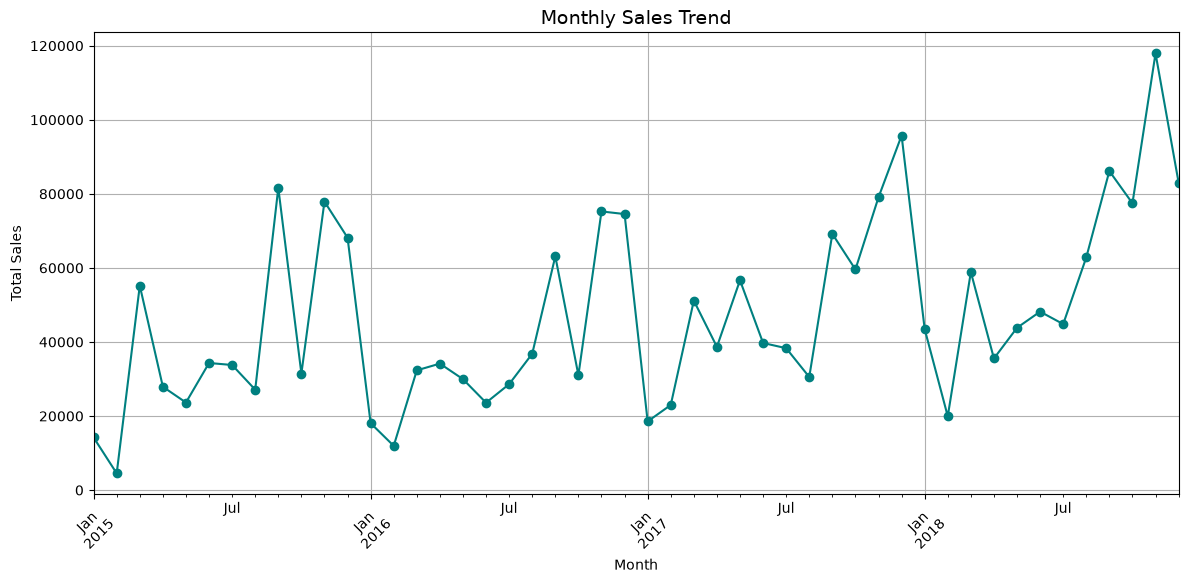

In [26]:
#Line Chart 
plt.figure(figsize = (14,6))
monthly_sales.plot(kind='line', marker='o', color='teal')
plt.title('Monthly Sales Trend', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation = 45)
plt.grid(True)
plt.show()

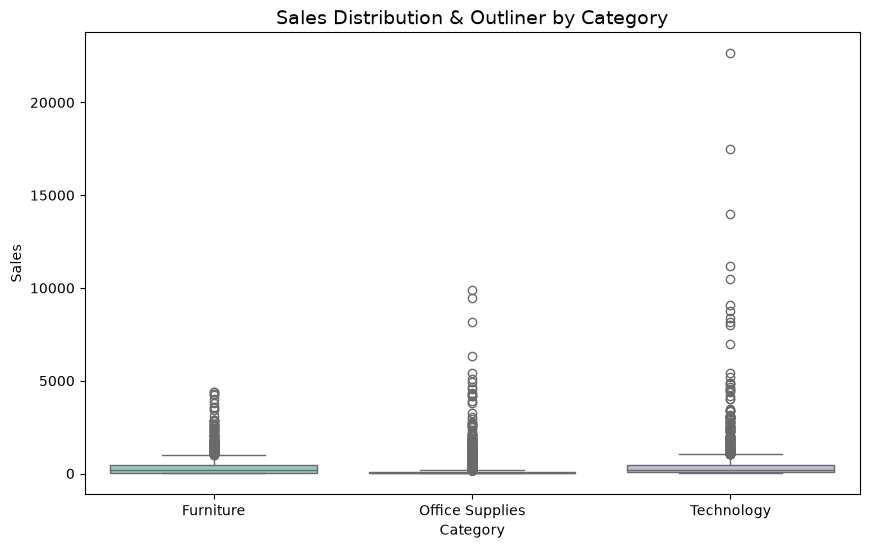

In [29]:
#Box plot
plt.figure(figsize= (10,6))
sns.boxplot(data = df, x ='Category', y = 'Sales', hue = 'Category', palette = 'Set3', legend = False)
plt.title('Sales Distribution & Outliner by Category', fontsize = 14)
plt.xlabel('Category')
plt.ylabel('Sales')
plt.show() 

Insight #3: Look at all those circles above each box - those are outliers, individual orders that sold for way more than typical.

Technology has the most extreme outlier - one single order near 22,000+
Office Supplies has the most small outliers (lots of circles) even though individual values are smaller
Furniture has the fewest outliers - its sales are more tightly packed
Notice all three boxes look "squashed" near the bottom (close to 0) - this confirms our earlier finding: most orders are small, but a few huge orders skew everything

In [30]:
#Correlation matrix + HeatMap
numeric_df = df[['Sales', 'Postal Code', 'Shipping Days']]
correlation = numeric_df.corr()
print(correlation)

                  Sales  Postal Code  Shipping Days
Sales          1.000000    -0.025588      -0.005712
Postal Code   -0.025588     1.000000      -0.009378
Shipping Days -0.005712    -0.009378       1.000000


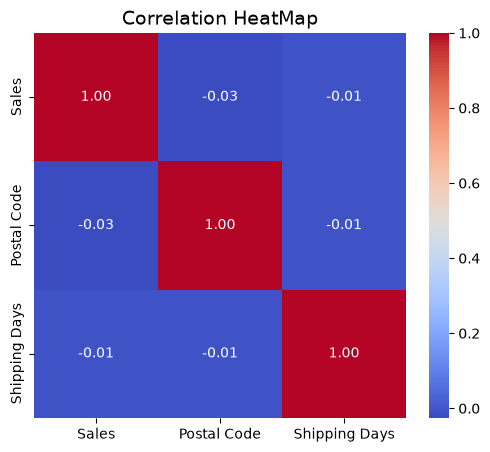

In [31]:
plt.figure(figsize = (6,5))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation HeatMap', fontsize = 14)
plt.show()

## EDA Insights - Superstore Sales Dataset

1. **Technology generates the highest revenue** (827K) among all categories, 
   followed by Furniture (728K) and Office Supplies ($705K).

2. **Mean Sales ($230.77) is much higher than Median Sales (54.49)** - this 
   gap indicates the presence of high-value outlier orders skewing the average.

3. **Boxplot confirms heavy outliers** across all categories, with Technology 
   having the single highest-value order (~22,000). Office Supplies has the 
   most frequent small outliers.

4. **Monthly sales show seasonal variation**, with peaks typically appearing 
   toward the end of the year (Nov-Dec), suggesting holiday season demand.

5. **Correlation analysis shows weak/no relationship** between Sales, Postal 
   Code, and Shipping Days - meaning shipping speed and location don't 
   significantly affect order value.